In [122]:
import scipy
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import h5py

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsOneClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

from scipy import stats

from spike_generator import generate_spikes

In [123]:
# load data
mat_lambda = scipy.io.loadmat(Path('data') / 'lambda_slow-gain.mat')
rate = mat_lambda['lambda']
mat_tuning = scipy.io.loadmat(Path('data') / 'tuning_slow-gain.mat')
tuning_curves = mat_tuning['tuning_curves']
mat_gain = scipy.io.loadmat(Path('data') / 'gain_slow-gain.mat')
gain = mat_gain['gain']

mat2 = scipy.io.loadmat(Path('data') / 'bin_sizes_all.mat')
bin_sizes_all = mat2['bin_sizes_all'][0]
# ibin = 11
ibin = -3

n_neurons = rate.shape[0]
n_trials = rate.shape[2]

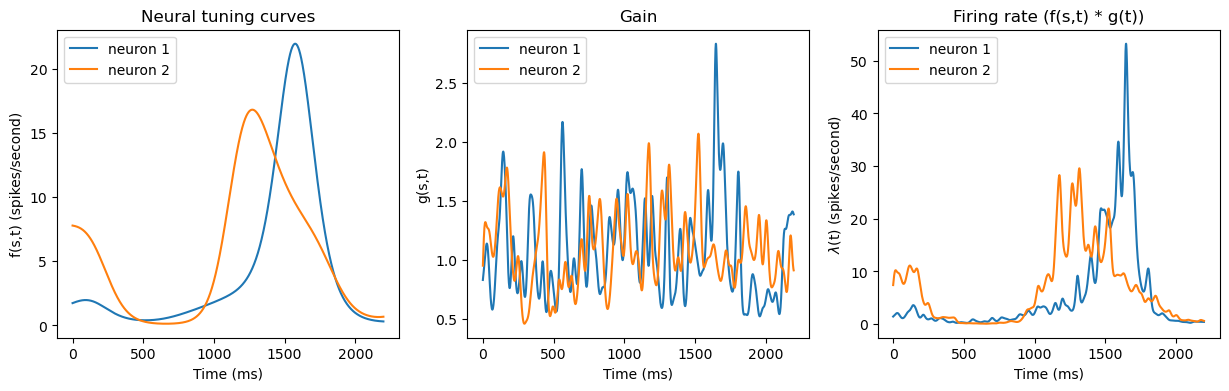

In [124]:
# pick two neurons only
neuron_idx = [12, 14]
# neuron_idx = [12, 13, 14, 15]

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(tuning_curves[neuron_idx, :, 0].T)
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('f(s,t) (spikes/second)')
axs[0].set_title('Neural tuning curves')
axs[0].legend(('neuron 1','neuron 2'))

axs[1].plot(gain[neuron_idx, :, 0].T)
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel('g(s,t)')
axs[1].set_title('Gain')
axs[1].legend(('neuron 1','neuron 2'))

axs[2].plot(rate[neuron_idx, :, 0].T)
axs[2].set_xlabel('Time (ms)')
axs[2].set_ylabel(r'$\lambda$(t) (spikes/second)')
axs[2].set_title('Firing rate (f(s,t) * g(t))')
axs[2].legend(('neuron 1','neuron 2'))

plt.show()

In [125]:
# simulate spikes
dt = 1e-3
spike_train = generate_spikes(rate[neuron_idx], dt) # create population response vectors

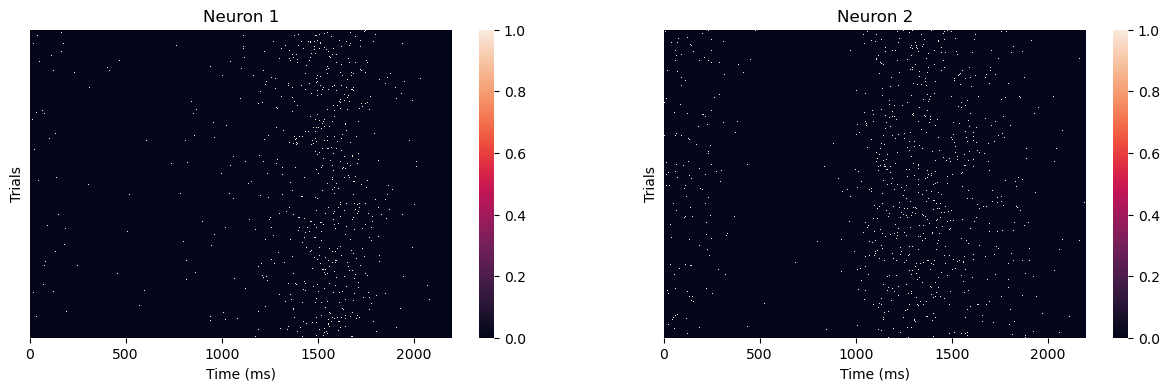

In [126]:
# plot spike trains
ticks = np.arange(0, spike_train.shape[1], 500)

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

sns.heatmap(spike_train[0].T, ax=axs[0], yticklabels=False)
axs[0].set_title('Neuron 1')

sns.heatmap(spike_train[1].T, ax=axs[1], yticklabels=False)
axs[1].set_title('Neuron 2')

for i in range(2):
    axs[i].set_xlabel('Time (ms)')
    axs[i].set_ylabel('Trials')
    axs[i].set_xticks(ticks)
    axs[i].set_xticklabels(ticks)
    axs[i].tick_params(axis='x', labelrotation=0)

plt.show()

In [127]:
# create population response vectors; the number of bins determine the number of representational locations
bin_length = int(bin_sizes_all[ibin] / dt)
n_bins = int(spike_train.shape[1] // bin_length)
spike_train_reshaped = np.reshape(spike_train, (len(neuron_idx), n_bins, bin_length, n_trials)) # n_neurons x n_bins x bin_length x n_trials
mean_spike_train = np.sum(spike_train_reshaped, axis=2) # n_neurons x n_bins x n_trials

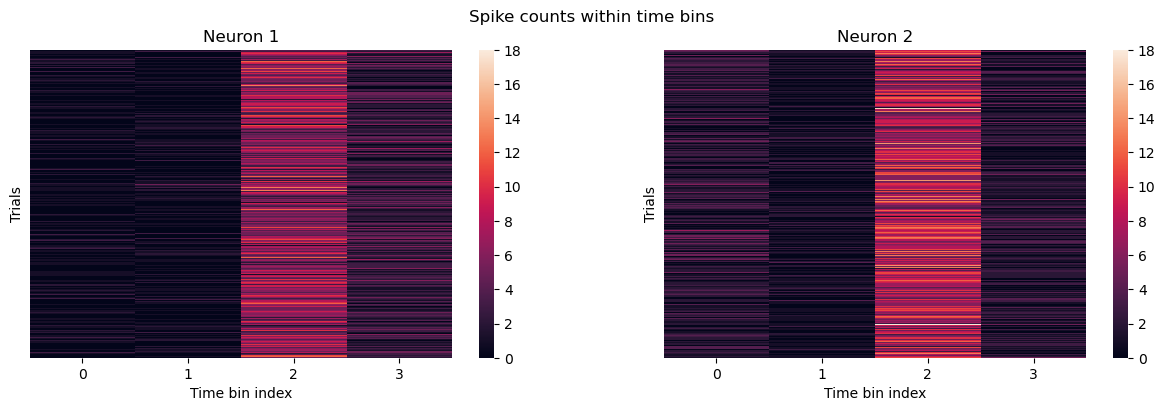

In [128]:
# plot binned spike counts
ticks = np.arange(0, spike_train.shape[1], 500)

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

sns.heatmap(mean_spike_train[0].T, ax=axs[0], yticklabels=False)
axs[0].set_title('Neuron 1')

sns.heatmap(mean_spike_train[1].T, ax=axs[1], yticklabels=False)
axs[1].set_title('Neuron 2')

for i in range(2):
    axs[i].set_xlabel('Time bin index')
    axs[i].set_ylabel('Trials')
    axs[i].tick_params(axis='x', labelrotation=0)

fig.suptitle('Spike counts within time bins')
plt.show()

In [129]:
# # check if total spike counts (over time) are still the same
# fig, axs = plt.subplots(1, 2, figsize=(13, 4))

# axs[0].plot(np.sum(spike_train[0], axis=0), np.sum(mean_spike_train[0], axis=0))
# axs[1].plot(np.sum(spike_train[1], axis=0), np.sum(mean_spike_train[1], axis=0))

In [130]:
# create data consistent with sklearn convention
X = mean_spike_train.transpose(1, 2, 0).reshape((-1, len(neuron_idx))) # n_samples x n_features
y = np.repeat(np.arange(n_bins), n_trials)

# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# initialize the SVM classifier with One-vs-One strategy
clf = SVC(decision_function_shape='ovo', kernel='linear')
# clf = SVC(decision_function_shape='ovo', kernel='rbf')
clf.fit(X_train, y_train)

# predict and evaluate the One-vs-One model
print("One-vs-One accuracy:", clf.score(X_test, y_test))
print("One-vs-One accuracy (manually compuated):", np.sum(clf.predict(X_test) == y_test) / len(y_test))

One-vs-One accuracy: 0.7075
One-vs-One accuracy (manually compuated): 0.7075


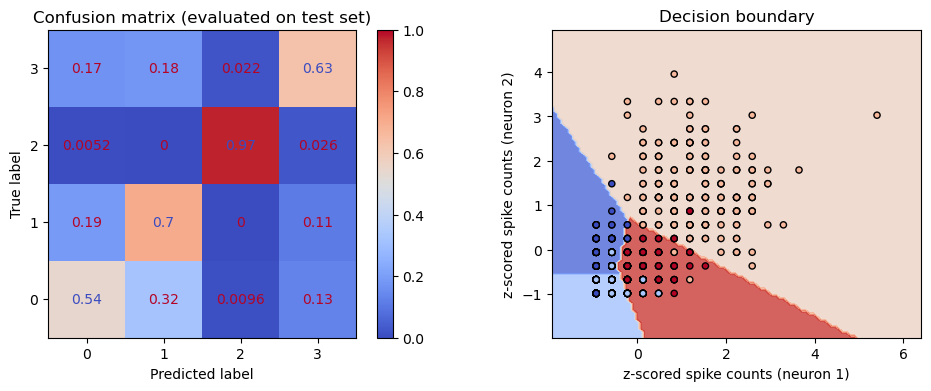

In [131]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

disp1 = ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, normalize='true', cmap='coolwarm', ax=axs[0]
)
disp1.im_.set_clim(0, 1)
axs[0].set_title('Confusion matrix (evaluated on test set)')
axs[0].invert_yaxis()

disp1 = DecisionBoundaryDisplay.from_estimator(
        clf, 
        X_test, 
        response_method="predict", 
        cmap=plt.cm.coolwarm, 
        alpha=0.8, 
        ax=axs[1], 
        xlabel='z-scored spike counts (neuron 1)', 
        ylabel='z-scored spike counts (neuron 2)',
    )
axs[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
# axs[1].set_xticks(())
# axs[1].set_yticks(())
axs[1].set_aspect('equal')
axs[1].set_title('Decision boundary')

plt.show()

In [132]:
# compute discriminability
discrim_mat = np.zeros((n_bins, n_bins))
count_mat = np.zeros((n_bins, n_bins))
y_pred = clf.predict(X_test)
trial_inds = np.arange(0, n_bins)

for idx, _ in enumerate(y_test):
    if y_pred[idx] == y_test[idx]:
        # for example, if there are 4 trials and the current bin is correctly classified to belong to trial 0, 
        # then store value "1" for trials [1, 2, 3]
        corr_trial_inds = trial_inds[trial_inds != y_test[idx]]
    else:
        # for example, if the first bin belongs to trial 0 but the current bin is incorrectly classified to belong to trial 2, 
        # then store value "1" only for trials [1, 3]
        corr_trial_inds = trial_inds[(trial_inds != y_test[idx]) & (trial_inds != y_pred[idx])]
    
    # store 1 for correct discrimination
    discrim_mat[y_test[idx], corr_trial_inds] += 1
    discrim_mat[corr_trial_inds, y_test[idx]] += 1 # disciminability matrix is symmetric

    # count every time a test trial index is visited
    count_mat[y_test[idx], :] += 1
    count_mat[:, y_test[idx]] += 1

prop_corr_mat = discrim_mat / count_mat
np.fill_diagonal(prop_corr_mat, 0.5)

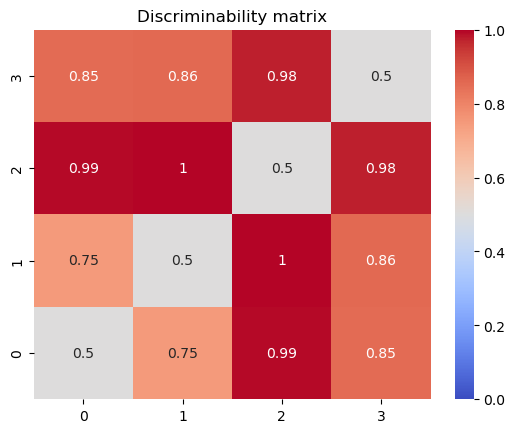

In [133]:
# plot discriminability matrix
sns.heatmap(prop_corr_mat, vmin=0, vmax=1, cmap='coolwarm', annot=True)
plt.title('Discriminability matrix')
plt.gca().invert_yaxis()